In [251]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from sklearn.decomposition import PCA


In [252]:
df=pd.read_csv("houses_flats_final.csv")

In [253]:
df.shape

(23081, 13)

In [254]:
df = df[df['price'] < df['price'].quantile(0.90)]

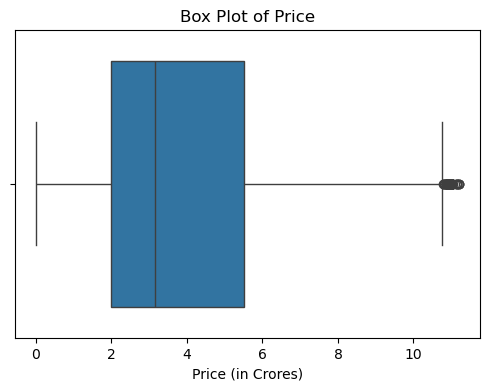

In [255]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x=df['price'])
plt.title('Box Plot of Price')
plt.xlabel('Price (in Crores)')
plt.show()

In [ ]:
df.head()

,bedrooms,baths,price,area_sqft,kitchens,store_rooms,is_gym,agePossession,property_type,is_servant_room,luxury_category,floor_category,furnishing_type
0,4.0,4.0,4.55,3264.0,1.0,1.0,No,New Property,flat,Yes,Very High,Mid Floor,Luxury Furnished
1,4.0,5.0,4.50,3318.4,1.0,0.0,No,New Property,flat,Yes,Very High,Mid Floor,Luxury Furnished
2,3.0,4.0,3.55,2720.0,1.0,1.0,Yes,New Property,flat,Yes,Very High,Mid Floor,Luxury Furnished
3,4.0,4.0,4.45,2067.2,2.0,1.0,No,New Property,flat,Yes,Very High,Mid Floor,Furnished
4,4.0,5.0,4.65,3318.4,1.0,1.0,No,New Property,flat,Yes,Very High,Mid Floor,Furnished


: 

: 

In [256]:
df.shape

(20754, 13)

In [220]:
df['furnishing_score'].value_counts()

furnishing_score
25    8552
15    3352
0     1713
49    1445
24     850
14     637
39     518
5      470
7      448
6      390
8      382
12     357
3      330
11     294
13     290
10     168
16     143
2      142
22     139
18     134
23     133
9      130
1      128
20      98
4       95
47      88
37      68
17      61
21      52
33      42
19      36
30      34
31      31
28      28
40      19
34      19
32      16
43      13
41      12
26      11
38       8
42       6
27       5
35       1
29       1
Name: count, dtype: int64

In [257]:
df['furnishing_type'] = pd.cut(
    df['furnishing_score'],
    bins=[-1, 0, 10, 25, 100],
    labels=[
        'Unfurnished',
        'Semi-Furnished',
        'Furnished',
        'Luxury Furnished'
    ]
)

In [258]:
df=df.drop(columns='furnishing_score')

In [259]:
df.head()

,bedrooms,baths,price,area_sqft,kitchens,store_rooms,gym,agePossession,property_type,has_servant_room,luxury_category,floor_category,furnishing_type
0,4.0,4.0,4.55,3264.0,1.0,1.0,0,New Property,flat,1,Very High,Mid Floor,Luxury Furnished
1,4.0,5.0,4.50,3318.4,1.0,0.0,0,New Property,flat,1,Very High,Mid Floor,Luxury Furnished
2,3.0,4.0,3.55,2720.0,1.0,1.0,1,New Property,flat,1,Very High,Mid Floor,Luxury Furnished
3,4.0,4.0,4.45,2067.2,2.0,1.0,0,New Property,flat,1,Very High,Mid Floor,Furnished
4,4.0,5.0,4.65,3318.4,1.0,1.0,0,New Property,flat,1,Very High,Mid Floor,Furnished


In [260]:
# Rename columns
df.rename(columns={
    'gym': 'is_gym',
    'has_servant_room': 'is_servant_room'
}, inplace=True)

df['is_gym'] = df['is_gym'].map({1: 'Yes', 0: 'No'})
df['is_servant_room'] = df['is_servant_room'].map({1: 'Yes', 0: 'No'})

In [261]:
df.columns

Index(['bedrooms', 'baths', 'price', 'area_sqft', 'kitchens', 'store_rooms',
       'is_gym', 'agePossession', 'property_type', 'is_servant_room',
       'luxury_category', 'floor_category', 'furnishing_type'],
      dtype='object')

In [262]:
# Split features and target
X = df.drop(columns=['price'])
y = df['price']

In [263]:
# Apply log1p transformation
y_transformed = np.log1p(y)

In [264]:
X.columns

Index(['bedrooms', 'baths', 'area_sqft', 'kitchens', 'store_rooms', 'is_gym',
       'agePossession', 'property_type', 'is_servant_room', 'luxury_category',
       'floor_category', 'furnishing_type'],
      dtype='object')

In [265]:
df.columns

Index(['bedrooms', 'baths', 'price', 'area_sqft', 'kitchens', 'store_rooms',
       'is_gym', 'agePossession', 'property_type', 'is_servant_room',
       'luxury_category', 'floor_category', 'furnishing_type'],
      dtype='object')

In [266]:
df.duplicated().sum()

np.int64(4523)

In [267]:
X.dtypes

bedrooms            float64
baths               float64
area_sqft           float64
kitchens            float64
store_rooms         float64
is_gym               object
agePossession        object
property_type        object
is_servant_room      object
luxury_category      object
floor_category       object
furnishing_type    category
dtype: object

In [268]:
X['floor_category'] = X['floor_category'].fillna('Low Floor')

### ordinal encoding

In [269]:
num_cols = [
    'bedrooms',
    'baths',
    'area_sqft',
    'kitchens',
    'store_rooms'
]

ordinal_cols = [
    'agePossession',
    'furnishing_type',
    'luxury_category',
    'floor_category',
    'is_gym',
    'is_servant_room',
    'property_type'
]



In [270]:
X.isnull().sum()

bedrooms           0
baths              0
area_sqft          0
kitchens           0
store_rooms        0
is_gym             0
agePossession      0
property_type      0
is_servant_room    0
luxury_category    0
floor_category     0
furnishing_type    0
dtype: int64

In [271]:
X['floor_category'].value_counts()

floor_category
Low Floor     16766
Mid Floor      3855
High Floor      133
Name: count, dtype: int64

In [272]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OrdinalEncoder(), ordinal_cols),
    ],
    remainder='passthrough'
)

In [273]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [274]:
# K-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

scores.mean(), scores.std()

(np.float64(0.8142316680117965), np.float64(0.00923416685158639))

In [275]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_transformed, test_size=0.2, random_state=42
)

In [276]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['bedrooms', 'baths',
                                                   'area_sqft', 'kitchens',
                                                   'store_rooms']),
                                                 ('cat', OrdinalEncoder(),
                                                  ['agePossession',
                                                   'furnishing_type',
                                                   'luxury_category',
                                                   'floor_category', 'is_gym',
                                                   'is_servant_room',
                                                   'property_type'])])),
                ('regressor', LinearRegression())])

In [277]:
y_pred = pipeline.predict(X_test)

In [278]:
y_pred = np.expm1(y_pred)

In [279]:
mean_absolute_error(np.expm1(y_test), y_pred)

0.8416025029459896

In [194]:
def scorer(model_name, model):

    output = []

    output.append(model_name)

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

    output.append(scores.mean())

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_transformed, test_size=0.2, random_state=42
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    y_pred = np.expm1(y_pred)

    output.append(mean_absolute_error(np.expm1(y_test), y_pred))

    return output

In [195]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

model_dict = {
    'linear_reg': LinearRegression(),
    'svr': SVR(),
    'ridge': Ridge(),
    'lasso': Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest': RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost': XGBRegressor()
}

In [280]:
model_output = []
for model_name, model in model_dict.items():
    model_output.append(scorer(model_name, model))

In [ ]:
model_output

[['linear_reg', np.float64(0.813888361001081), 1.2191634552902566],
 ['svr', np.float64(0.873445874665095), 0.9165421663176134],
 ['ridge', np.float64(0.8138884702631788), 1.2191399024439495],
 ['lasso', np.float64(-0.0004949158092175665), 2.617427868152152],
 ['decision tree', np.float64(0.8461785793045312), 0.9681584678032896],
 ['random forest', np.float64(0.88004047678835), 0.880399015784499],
 ['extra trees', np.float64(0.8712195841476355), 0.9021090105517499],
 ['gradient boosting', np.float64(0.8810619273331497), 0.924403319029959],
 ['adaboost', np.float64(0.8505785900453304), 1.0403347944130439],
 ['mlp', np.float64(0.8696009614448776), 0.927195083682104],
 ['xgboost', np.float64(0.8888826986299929), 0.8711984623733205]]

: 

: 

In [158]:
model_df = pd.DataFrame(model_output, columns=['name', 'r2', 'mae'])

In [159]:
model_df.sort_values(['mae'])

,name,r2,mae
10,xgboost,0.888883,0.871198
5,random forest,0.880040,0.880399
6,extra trees,0.871220,0.902109
1,svr,0.873446,0.916542
7,gradient boosting,0.881062,0.924403
9,mlp,0.869601,0.927195
4,decision tree,0.846179,0.968158
8,adaboost,0.850579,1.040335
2,ridge,0.813888,1.219140
0,linear_reg,0.813888,1.219163


In [160]:
df.columns

Index(['bedrooms', 'baths', 'price', 'area_sqft', 'kitchens', 'store_rooms',
       'is_gym', 'agePossession', 'property_type', 'is_servant_room',
       'luxury_category', 'floor_category', 'furnishing_type'],
      dtype='object')

In [45]:
import category_encoders as ce
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Columns
num_cols = [
    'bedrooms',
    'baths',
    'area_sqft',
    'kitchens',
    'store_rooms'
]

target_cols = [
    'agePossession',
    'luxury_category',
    'floor_category',
    'furnishing_type'
]

binary_cols = [
    'is_gym',
    'is_servant_room',
    'property_type'
]





# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('target_enc', ce.TargetEncoder(), target_cols),
        ('cat', OrdinalEncoder(), binary_cols)
    ],
    remainder='passthrough'
)

In [281]:
X['is_gym'] = X['is_gym'].map({'Yes': 1, 'No': 0})
X['is_servant_room'] = X['is_servant_room'].map({'Yes': 1, 'No': 0})
X['property_type'] = X['property_type'].map({'flat': 0, 'house': 1})

In [197]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Numerical features
num_cols = [
    'bedrooms',
    'baths',
    'area_sqft',
    'kitchens',
    'store_rooms'
]

# Ordered categorical features
ordinal_cols = [
    'agePossession',        # New → Old
    'luxury_category',      # Low → Medium → High → Very High
    'floor_category',       # Low → Mid → High
    'furnishing_type'       # Unfurnished → Semi → Furnished → Luxury
]

# Binary (must already be 0/1)
binary_cols = [
    'is_gym',
    'is_servant_room',
    'property_type'
]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('ord', OrdinalEncoder(), ordinal_cols),
        ('bin', 'passthrough', binary_cols)
    ],
    remainder='drop'   # IMPORTANT: avoid duplicate columns
)

In [144]:
X.select_dtypes(include='object').columns

Index(['agePossession', 'luxury_category', 'floor_category'], dtype='object')

In [145]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [146]:
# K-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

scores.mean(), scores.std()

(np.float64(0.813888361001081), np.float64(0.008295916922702925))

In [147]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_transformed, test_size=0.2, random_state=42
)

In [148]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['bedrooms', 'baths',
                                                   'area_sqft', 'kitchens',
                                                   'store_rooms']),
                                                 ('ord', OrdinalEncoder(),
                                                  ['agePossession',
                                                   'luxury_category',
                                                   'floor_category',
                                                   'furnishing_type']),
                                                 ('bin', 'passthrough',
                                                  ['is_gym', 'is_servant_room',
                                                   'property_type'])])),
                ('regressor', LinearRegression())])

In [149]:
y_pred = pipeline.predict(X_test)

In [150]:
y_pred = np.expm1(y_pred)

In [151]:
mean_absolute_error(np.expm1(y_test), y_pred)

1.2191634552902566

In [152]:
model_output = []
for model_name, model in model_dict.items():
    model_output.append(scorer(model_name, model))

In [153]:
model_df = pd.DataFrame(model_output, columns=['name', 'r2', 'mae'])
model_df.sort_values(['mae'])

,name,r2,mae
10,xgboost,0.888866,0.871172
5,random forest,0.880082,0.877281
6,extra trees,0.871230,0.902889
1,svr,0.873446,0.916542
7,gradient boosting,0.881058,0.924391
9,mlp,0.872433,0.926301
4,decision tree,0.846368,0.964612
8,adaboost,0.848851,1.042163
2,ridge,0.813888,1.219140
0,linear_reg,0.813888,1.219163


In [282]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'regressor__n_estimators': [50, 100, 200, 300],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__max_samples': [0.1, 0.25, 0.5, 1.0],
    'regressor__max_features': ['auto', 'sqrt']
}

In [283]:
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('ord', OrdinalEncoder(), ordinal_cols),
        ('bin', 'passthrough', binary_cols)
    ],
    remainder='drop'   # IMPORTANT: avoid duplicate columns
)

In [284]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor())
])

In [ ]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

search = GridSearchCV(
    pipeline,
    param_grid,
    cv=kfold,
    scoring='r2',
    n_jobs=-1,
    verbose=4
)

search.fit(X, y_transformed)

Fitting 10 folds for each of 128 candidates, totalling 1280 fits


In [ ]:
final_pipe = search.best_estimator_

: 

In [245]:

search.best_params_


{'regressor__max_depth': 20,
 'regressor__max_features': 'sqrt',
 'regressor__max_samples': 0.5,
 'regressor__n_estimators': 300}

In [246]:

search.best_score_



np.float64(0.8840932807291748)

In [247]:
final_pipe.fit(X, y_transformed)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['bedrooms', 'baths',
                                                   'area_sqft', 'kitchens',
                                                   'store_rooms']),
                                                 ('ord', OrdinalEncoder(),
                                                  ['agePossession',
                                                   'furnishing_type',
                                                   'luxury_category',
                                                   'floor_category', 'is_gym',
                                                   'is_servant_room',
                                                   'property_type']),
                                                 ('bin', 'passthrough',
                                                  ['is_gym', 'is_servant_room',
                                                   'property_type'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=20, max_features='sqrt',
                                       max_samples=0.5, n_estimators=300))])

In [248]:
y_pred = final_pipe.predict(X_test)

In [249]:
y_pred = np.expm1(y_pred)

In [250]:
mean_absolute_error(np.expm1(y_test), y_pred)

0.7237888071009544